# Prerequisites: Python, Tools, and Course Philosophy

## Purpose of This Notebook

This notebook serves as a **quick-start reference**, not a full Python tutorial. It covers:

1. The essential Python you need to follow the course.
2. The key libraries we use (NumPy, Matplotlib, Manim) and what they're for.
3. The **pedagogical philosophy** of this course — why we build things from scratch before using packages.

If you already know Python, skim the language refresher and focus on the philosophy section.

For the **mathematical** prerequisites (sets, logarithms, summation notation, calculus), see [02_math_foundations.ipynb](02_math_foundations.ipynb).

## Setup

Before running this notebook, make sure you have followed the [installation guide](INSTALL.md).

In [ ]:
# Environment detection & setup
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

# Ensure MiKTeX is on PATH (Windows — conda env may not inherit system PATH)
_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

# Apply course style
sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    """Notebook-level configuration: paths, LaTeX detection, Manim defaults."""

    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        """Call after `from manim import *` to configure Manim for notebook use."""
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr: str, **kwargs):
        """MathTex if LaTeX is available, otherwise a cleaned-up Text fallback."""
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        plain = expr.replace(r"\hat{P}", "P̂").replace(r"\text{", "").replace("}", "")
        plain = plain.replace(r"\tfrac{1}{6}", "1/6").replace("$", "")
        return Text(plain, **kwargs)

    def save_gifs(self, clean: bool = True):
        """Copy final GIFs to media/gifs/ at repo root and optionally clean temp files."""
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

print(f"Python {sys.version}")
print(f"NumPy  {np.__version__}")
print("Setup OK.")

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]
NumPy  2.4.3
Setup OK.


---

## Part 1: Python Language Refresher

This section is a **condensed reference** of the Python features we use throughout the course. For a comprehensive tutorial, see the [official Python tutorial](https://docs.python.org/3/tutorial/).

### 1.1 Variables and Types

Python is dynamically typed — you don't declare types, but every value has one.

In [ ]:
n = 100  # int
p = 0.5  # float
name = "Bernoulli"  # str
fair = True  # bool

print(type(n), type(p), type(name), type(fair))

# f-strings — the way we format output throughout the course
print(f"Flipping a {'fair' if fair else 'biased'} coin {n} times with p = {p}")
print(f"Named after {name}, who lived in the {17}th century")

<class 'int'> <class 'float'> <class 'str'> <class 'bool'>
Flipping a fair coin 100 times with p = 0.5
Named after Bernoulli, who lived in the 17th century


### 1.2 Collections: Lists, Tuples, Dicts, Sets

| Type    | Syntax      | Mutable? | Use case                                         |
|---------|-------------|----------|--------------------------------------------------|
| `list`  | `[1, 2, 3]` | Yes      | Ordered sequence, most common                    |
| `tuple` | `(1, 2, 3)` | No       | Fixed-length records, dict keys                  |
| `dict`  | `{"a": 1}`  | Yes      | Key-value lookup (frequency tables, parameters)  |
| `set`   | `{1, 2, 3}` | Yes      | Unique elements, set operations (sample spaces!) |

In [3]:
# Lists — ordered, mutable
rolls = [3, 1, 4, 1, 5, 9, 2, 6]
print(f"First roll: {rolls[0]}, last roll: {rolls[-1]}, count of 1s: {rolls.count(1)}")

# Dicts — key-value lookup
freq = {}
for r in rolls:
    freq[r] = freq.get(r, 0) + 1
print(f"Frequency table: {freq}")

# Sets — unique elements, great for sample spaces
omega = {1, 2, 3, 4, 5, 6}
evens = {2, 4, 6}
print(f"Odd faces: {omega - evens}")

First roll: 3, last roll: 6, count of 1s: 2
Frequency table: {3: 1, 1: 2, 4: 1, 5: 1, 9: 1, 2: 1, 6: 1}
Odd faces: {1, 3, 5}


### 1.3 Indexing and Slicing

Python uses **zero-based indexing**. Slicing with `[start:stop:step]` extracts sub-sequences — `stop` is always excluded. Negative indices count from the end.

In [ ]:
data = [10, 20, 30, 40, 50, 60, 70, 80]

print(f"data[0]     = {data[0]}")  # first element
print(f"data[-1]    = {data[-1]}")  # last element
print(f"data[2:5]   = {data[2:5]}")  # elements at index 2, 3, 4
print(f"data[:3]    = {data[:3]}")  # first three
print(f"data[5:]    = {data[5:]}")  # from index 5 to end
print(f"data[::2]   = {data[::2]}")  # every other element
print(f"data[::-1]  = {data[::-1]}")  # reversed

# Slicing works on strings too
s = "probability"
print(f"'{s}' → first 4 chars: '{s[:4]}', last 3: '{s[-3:]}'")

# And on NumPy arrays (we use this constantly)
arr = np.arange(10)
print(f"arr[3:7] = {arr[3:7]}")

data[0]     = 10
data[-1]    = 80
data[2:5]   = [30, 40, 50]
data[:3]    = [10, 20, 30]
data[5:]    = [60, 70, 80]
data[::2]   = [10, 30, 50, 70]
data[::-1]  = [80, 70, 60, 50, 40, 30, 20, 10]
'probability' → first 4 chars: 'prob', last 3: 'ity'
arr[3:7] = [3 4 5 6]


### 1.4 Control Flow

Python uses **indentation** (4 spaces) to define blocks — there are no braces `{}` or `end` keywords.

In [ ]:
# if / elif / else
x = 7
if x % 2 == 0:
    print(f"{x} is even")
else:
    print(f"{x} is odd")

# for loop
total = 0
for i in range(1, 11):  # 1, 2, ..., 10
    total += i
print(f"Sum 1..10 = {total}")

# List comprehension — concise loop-in-a-list
squares = [i**2 for i in range(1, 6)]
print(f"Squares: {squares}")

7 is odd
Sum 1..10 = 55
Squares: [1, 4, 9, 16, 25]


In [ ]:
# while loop — repeat until a condition is met
count = 0
rng_local = np.random.default_rng(7)
while rng_local.random() < 0.8:  # ~80% chance of continuing each step
    count += 1
print(f"while loop stopped after {count} iterations")

# enumerate — loop with an index
names = ["Bernoulli", "Gauss", "Poisson"]
for i, name in enumerate(names):
    print(f"  {i}: {name}")

# zip — loop over two sequences in parallel
faces = [1, 2, 3, 4, 5, 6]
probs = [1 / 6] * 6
print(f"zip example: {list(zip(faces, probs))[:3]}")

# Ternary expression — one-line conditional
x = 42
label = "even" if x % 2 == 0 else "odd"
print(f"{x} is {label}")

# Dict comprehension
sq_dict = {n: n**2 for n in range(1, 6)}
print(f"Squares dict: {sq_dict}")

while loop stopped after 1 iterations
  0: Bernoulli
  1: Gauss
  2: Poisson
zip example: [(1, 0.16666666666666666), (2, 0.16666666666666666), (3, 0.16666666666666666)]
42 is even
Squares dict: {1: 1, 2: 4, 3: 9, 4: 16, 5: 25}


### 1.5 Functions

Functions are defined with `def`. They are the primary way we organise reusable logic.

In [ ]:
def factorial(n):
    """Compute n! using a loop."""
    result = 1
    for i in range(2, n + 1):
        result *= i
    return result


print(f"5! = {factorial(5)}")
print(f"10! = {factorial(10)}")

5! = 120
10! = 3628800


In [ ]:
# Default arguments and keyword arguments
def simulate_flips(n=100, p=0.5, seed=None):
    """Simulate n coin flips with probability p of heads."""
    rng = np.random.default_rng(seed)
    flips = rng.random(n) < p
    return flips.sum()  # number of heads


print(f"Fair coin, 100 flips:   {simulate_flips()} heads")
print(f"Biased coin, 100 flips: {simulate_flips(p=0.8)} heads")
print(f"Reproducible:           {simulate_flips(seed=42)} heads")

# Lambda — anonymous one-line functions (handy for sorting, filtering)
data = [("Gauss", 1777), ("Bayes", 1701), ("Poisson", 1781)]
data_sorted = sorted(data, key=lambda x: x[1])
print(f"Sorted by birth year: {data_sorted}")

Fair coin, 100 flips:   52 heads
Biased coin, 100 flips: 77 heads
Reproducible:           53 heads
Sorted by birth year: [('Bayes', 1701), ('Gauss', 1777), ('Poisson', 1781)]


### 1.6 Classes (Brief)

A **class** bundles data and the functions that operate on it. We use classes sparingly in this course (mostly for Manim scenes), but you should recognise the pattern.

See the [official classes tutorial](https://docs.python.org/3/tutorial/classes.html) for the full story.

In [ ]:
class Die:
    """A simple fair die."""

    def __init__(self, faces=6):
        self.faces = faces  # instance attribute

    def roll(self, n=1):
        """Roll the die n times and return the results."""
        rng = np.random.default_rng()
        return rng.integers(1, self.faces + 1, size=n)


d6 = Die(6)
print(f"Three rolls of a d6: {d6.roll(3)}")

d20 = Die(20)
print(f"One roll of a d20:   {d20.roll(1)}")

Three rolls of a d6: [1 3 3]
One roll of a d20:   [12]


### 1.7 Imports and Modules

Python's power comes from its ecosystem. We import functionality with `import`:

```python
import numpy as np                  # convention: short alias
from math import comb               # import one specific function
from amstats.plotting import apply_style  # from our own package
```

The key libraries in this course:

| Library        | What we use it for                             | Docs                                                            |
|----------------|------------------------------------------------|-----------------------------------------------------------------|
| **NumPy**      | Arrays, random numbers, vectorised math        | [numpy.org/doc](https://numpy.org/doc/stable/)                  |
| **Matplotlib** | Static plots and figures                       | [matplotlib.org](https://matplotlib.org/stable/contents.html)   |
| **SciPy**      | Distributions, optimisation, statistical tests | [docs.scipy.org](https://docs.scipy.org/doc/scipy/)             |
| **Manim**      | Animated visualisations                        | [docs.manim.community](https://docs.manim.community/en/stable/) |
| **Pandas**     | Tabular data manipulation                      | [pandas.pydata.org](https://pandas.pydata.org/docs/)            |
| **PyMC**       | Bayesian modelling (Modules 07–09)             | [pymc.io](https://www.pymc.io/projects/docs/en/stable/)         |

You do **not** need to know all of these upfront. We introduce each one when it becomes relevant.

---

## Part 2: NumPy in 5 Minutes

NumPy is the foundation of scientific Python. The core idea: operate on **whole arrays at once** instead of looping element by element.

In [ ]:
# Creating arrays
a = np.array([1, 2, 3, 4, 5])
print(f"Array: {a}, dtype: {a.dtype}, shape: {a.shape}")

# Vectorised operations — no loop needed
print(f"a * 2     = {a * 2}")
print(f"a ** 2    = {a**2}")
print(f"sum(a)    = {np.sum(a)}")
print(f"mean(a)   = {np.mean(a)}")
print(f"std(a)    = {np.std(a, ddof=1):.4f}")

In [12]:
# Random number generation — we use this constantly for simulations
rng = np.random.default_rng(42)  # seed for reproducibility

coin_flips = rng.choice(["H", "T"], size=10)
print(f"10 coin flips: {coin_flips}")

die_rolls = rng.integers(1, 7, size=10)
print(f"10 die rolls:  {die_rolls}")

normals = rng.normal(loc=0, scale=1, size=5)
print(f"5 standard normals: {np.round(normals, 3)}")

10 coin flips: ['H' 'T' 'T' 'H' 'H' 'T' 'H' 'T' 'H' 'H']
10 die rolls:  [4 6 5 5 5 5 4 1 6 3]
5 standard normals: [0.879 0.778 0.066 1.127 0.468]


### Why vectorisation matters

In statistics we often simulate millions of trials. Loops in Python are slow; NumPy operations on arrays are fast because they run in compiled C under the hood.

In [ ]:
# Speed comparison: mean of 1 million numbers
import time

data = rng.random(1_000_000)

# Pure Python loop
t0 = time.perf_counter()
total = 0
for x in data:
    total += x
mean_loop = total / len(data)
t_loop = time.perf_counter() - t0

# NumPy
t0 = time.perf_counter()
mean_np = np.mean(data)
t_np = time.perf_counter() - t0

print(f"Loop:  {mean_loop:.6f} in {t_loop * 1000:.1f} ms")
print(f"NumPy: {mean_np:.6f} in {t_np * 1000:.2f} ms")
print(f"NumPy is ~{t_loop / t_np:.0f}x faster")

---

## Part 3: Matplotlib in 5 Minutes

Matplotlib produces the static plots we use alongside Manim animations.

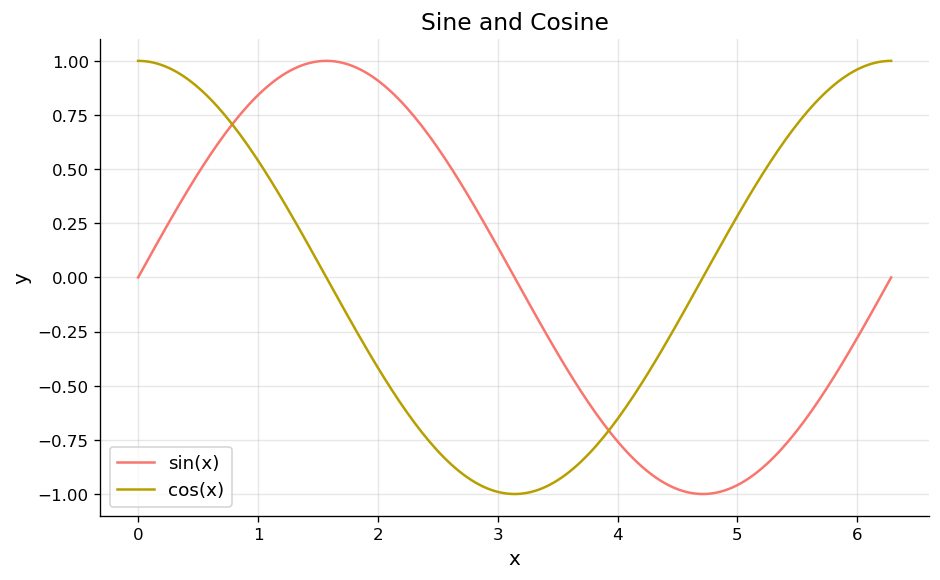

In [10]:
# Basic line plot
x = np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots()
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Sine and Cosine")
ax.legend()
plt.tight_layout()
plt.show()

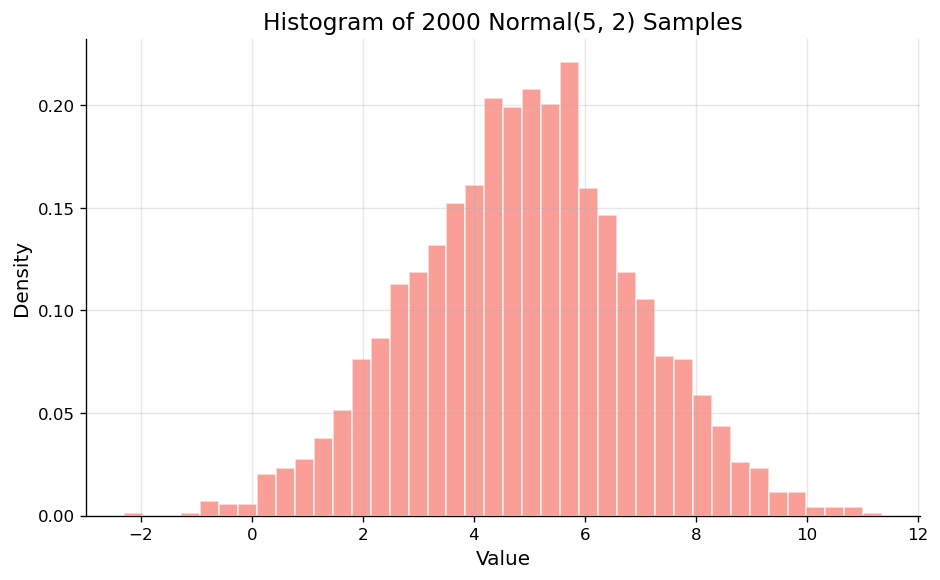

In [13]:
# Histogram — the workhorse of statistics
samples = rng.normal(loc=5, scale=2, size=2000)

fig, ax = plt.subplots()
ax.hist(samples, bins=40, density=True, alpha=0.7, edgecolor="white")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title("Histogram of 2000 Normal(5, 2) Samples")
plt.tight_layout()
plt.show()

Notice the **course color palette** is applied automatically by `apply_style()` in the setup cell. All plots across all notebooks share a consistent look. See the [Matplotlib tutorials](https://matplotlib.org/stable/tutorials/index.html) for more plot types.

---

## Part 4: Course Philosophy — From Scratch, Then Professional

This course follows a deliberate **three-stage pedagogy** for every major statistical method:

### Stage 1: Theory

We develop the mathematical foundations in lecture prose — definitions, theorems, derivations — supported by Manim animations that make the ideas visual.

### Stage 2: From Scratch

We implement the method **by hand in plain Python and NumPy**. No `scipy.stats`, no `statsmodels`, no `sklearn` — just loops, arrays, and the formulas from Stage 1.

This is where real understanding happens. When you've written the MLE optimizer yourself, you know what `scipy.optimize.minimize` is actually doing. When you've coded the bootstrap loop, `scipy.stats` confidence intervals aren't magic anymore.

### Stage 3: Professional Package

Once you understand the mechanics, we introduce the professional library that does it properly. We explain what it does internally, compare its output to our scratch implementation, and discuss what the library handles that we didn't (edge cases, convergence guarantees, numerical stability).

### How this plays out across the course

| Module                | From Scratch                                    | Professional Package            |
|-----------------------|-------------------------------------------------|---------------------------------|
| 01 Probability        | Set operations, classical probability in Python | `math.comb`, `itertools`        |
| 02 Distributions      | PMF/PDF functions in NumPy                      | `scipy.stats`                   |
| 03 Descriptive Stats  | `mean()`, `var()`, `median()` with loops        | NumPy, Pandas                   |
| 04 Estimation         | Gradient-ascent MLE in NumPy                    | `scipy.optimize`, `statsmodels` |
| 05 Hypothesis Testing | t-test from the formula                         | `scipy.stats.ttest_ind`         |
| 06 Linear Models      | OLS via normal equations                        | `statsmodels.OLS`               |
| 07 Bayesian           | Metropolis-Hastings in ~50 lines                | PyMC                            |
| 08–12                 | Conceptual understanding + professional tools   | PyMC, ArviZ, DoWhy              |

In the early modules (01–06) we lean heavily on the from-scratch stage. In the later modules (07+), the algorithms become too complex to implement robustly from scratch (MCMC, variational inference), so we focus more on understanding the concepts and using professional tools effectively.

### Example: computing the mean

Here's the pattern in miniature:

In [ ]:
# Stage 2: FROM SCRATCH — compute the mean with a loop
data = [4, 7, 13, 2, 8]

total = 0
for x in data:
    total += x
mean_scratch = total / len(data)
print(f"From scratch: mean = {mean_scratch}")

# Stage 3: PROFESSIONAL — use NumPy
mean_numpy = np.mean(data)
print(f"NumPy:        mean = {mean_numpy}")

# Same answer! But NumPy handles edge cases (NaN, empty arrays, dtypes)
# and is orders of magnitude faster on large data.

The goal is simple: **never use a tool you don't understand**. By the end of this course, when you call `scipy.stats.ttest_ind()`, you'll know exactly what computation is happening behind that function call — because you built it yourself first.

---

## Part 5: Manim — Our Visualisation Engine

Throughout this course we use [Manim Community Edition](https://docs.manim.community/en/stable/) to create animated figures that illustrate statistical concepts. You do **not** need to learn Manim yourself — the animation code is provided in each notebook and you just run the cells.

But if you're curious, here's the basic structure. A Manim **Scene** is a Python class with a `construct` method that describes what to draw and animate:

In [15]:
from manim import *

cfg.apply_manim_config()

from amstats.manim_utils import C

Manim Community v0.18.1

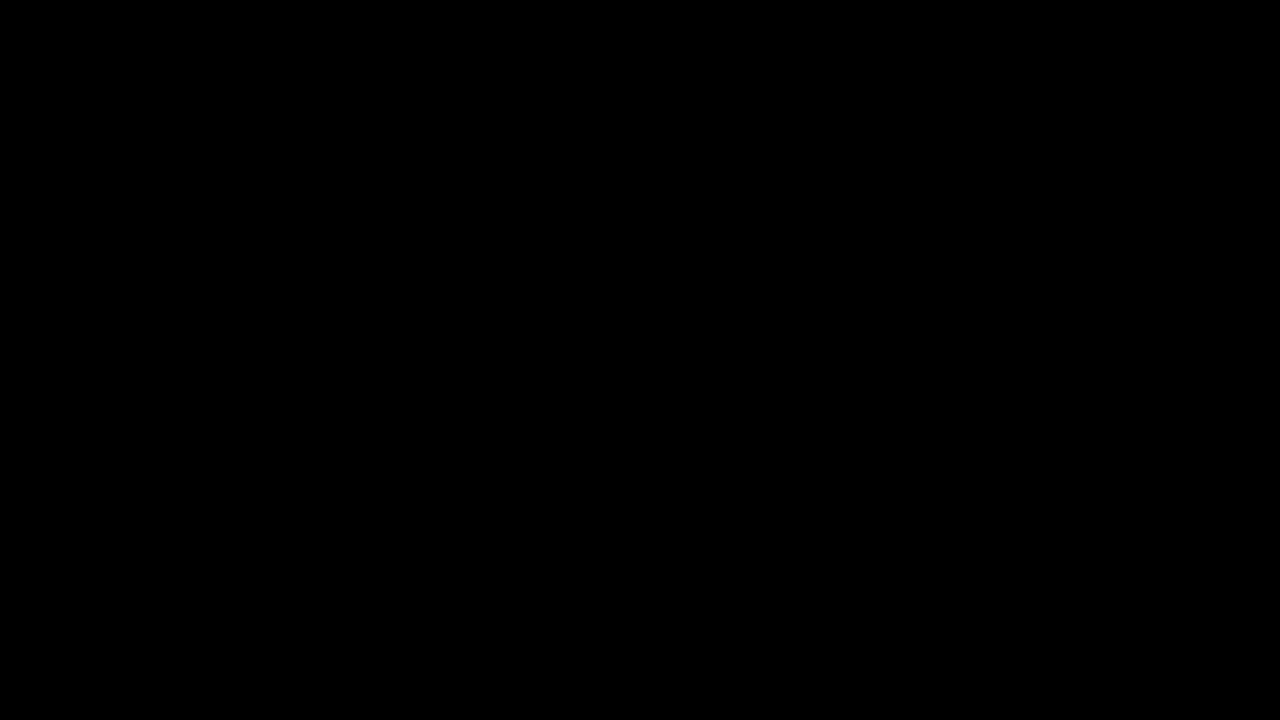

In [16]:
%%manim -qm -v WARNING HelloManim


class HelloManim(Scene):
    def construct(self):
        # Create objects
        title = Text("Welcome to the Course!", font_size=36)
        circle = Circle(radius=1.5, color=C.PERIWINKLE, fill_opacity=0.3)
        square = Square(side_length=3, color=C.SALMON, fill_opacity=0.3)

        # Animate them
        self.play(Write(title))
        self.play(title.animate.to_edge(UP))
        self.play(Create(circle))
        self.play(Transform(circle, square))
        self.play(FadeOut(circle), FadeOut(title))
        self.wait(0.5)

The `%%manim` magic renders the scene directly below the cell as a GIF. In the statistics notebooks, these animations will show things like convergence of relative frequencies, probability distributions morphing, regression lines fitting to data, and MCMC samplers exploring posterior surfaces.

If you want to learn Manim itself, the [Manim Community tutorials](https://docs.manim.community/en/stable/tutorials.html) are excellent.

---

## Key Takeaways

1. **Python basics** — variables, collections, slicing, control flow, functions, classes, imports. If any of these are unfamiliar, work through the [official Python tutorial](https://docs.python.org/3/tutorial/) before proceeding.
2. **NumPy** — arrays and vectorised operations are the foundation of all our numerical work.
3. **Matplotlib** — our tool for static plots; the course style is applied automatically.
4. **From scratch first, packages second** — we implement every method by hand before using the professional library, so you always understand what's happening under the hood.
5. **Manim** — produces the animated figures. You don't need to learn it; just run the cells.

**Next:** [Module 01 — Probability Basics](../01_probability_basics/01_sample_spaces.ipynb) — Sample spaces, events, and the axioms of probability.

In [17]:
# Save final GIFs to media/gifs/ at repo root and clean up local temp render files.
# Set clean=False to keep the temp files for debugging.
cfg.save_gifs(clean=True)

  ✓ media/gifs/HelloManim@2026-03-19@12-38-22.gif
  ✓ media/gifs/HelloManim_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
